<a href="https://colab.research.google.com/github/Apurwa127/Diabetes-risk-Assessment-for-Hack-Trek/blob/main/Hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title: AI-Powered Risk Assessment Tool**

**Problem Statement:
Diabetes often goes undetected until complication arises. The purpose of this model is to help patient and healthcare worker assess diabetes before any complications. It provides an automated summary for early screening.**

**Imports**

In [90]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import pickle
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


**Load and Read Dataset**

In [91]:
df = pd.read_csv('/content/Healthcare-Diabetes.csv')
df

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
2763,2764,2,75,64,24,55,29.7,0.370,33,0
2764,2765,8,179,72,42,130,32.7,0.719,36,1
2765,2766,6,85,78,0,0,31.2,0.382,42,0
2766,2767,0,129,110,46,130,67.1,0.319,26,1


**Find any duplicate values**

In [92]:
df = df.drop_duplicates()
df

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148,72,35,0,33.6,0.627,50,1
1,2,1,85,66,29,0,26.6,0.351,31,0
2,3,8,183,64,0,0,23.3,0.672,32,1
3,4,1,89,66,23,94,28.1,0.167,21,0
4,5,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
2763,2764,2,75,64,24,55,29.7,0.370,33,0
2764,2765,8,179,72,42,130,32.7,0.719,36,1
2765,2766,6,85,78,0,0,31.2,0.382,42,0
2766,2767,0,129,110,46,130,67.1,0.319,26,1


In [93]:
df.nunique()

,0
Id,2768
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,53
Insulin,187
BMI,253
DiabetesPedigreeFunction,523
Age,52
Outcome,2


In [94]:
df.isna().any()

,0
Id,False
Pregnancies,False
Glucose,False
BloodPressure,False
SkinThickness,False
Insulin,False
BMI,False
DiabetesPedigreeFunction,False
Age,False
Outcome,False


**This dataset had a lot of "0" values and it was most likely a place holder. I went ahead and changed the 0 value to "nan" and replaced it with median**

In [95]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols] = df[cols].replace(0, np.nan)
df.fillna(df.median(numeric_only=True), inplace = True)
df

,Id,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1,6,148.0,72.0,35.0,126.0,33.6,0.627,50,1
1,2,1,85.0,66.0,29.0,126.0,26.6,0.351,31,0
2,3,8,183.0,64.0,29.0,126.0,23.3,0.672,32,1
3,4,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,5,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...,...
2763,2764,2,75.0,64.0,24.0,55.0,29.7,0.370,33,0
2764,2765,8,179.0,72.0,42.0,130.0,32.7,0.719,36,1
2765,2766,6,85.0,78.0,29.0,126.0,31.2,0.382,42,0
2766,2767,0,129.0,110.0,46.0,130.0,67.1,0.319,26,1


In [96]:
df['Pregnancies'].unique()

array([ 6,  1,  8,  0,  5,  3, 10,  2,  4,  7,  9, 11, 13, 15, 17, 12, 14])

**Splitted the dataset between dependent and independent variable**

In [97]:
X = df.drop(['Id', 'Outcome'], axis = 'columns')
X

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148.0,72.0,35.0,126.0,33.6,0.627,50
1,1,85.0,66.0,29.0,126.0,26.6,0.351,31
2,8,183.0,64.0,29.0,126.0,23.3,0.672,32
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33
...,...,...,...,...,...,...,...,...
2763,2,75.0,64.0,24.0,55.0,29.7,0.370,33
2764,8,179.0,72.0,42.0,130.0,32.7,0.719,36
2765,6,85.0,78.0,29.0,126.0,31.2,0.382,42
2766,0,129.0,110.0,46.0,130.0,67.1,0.319,26


In [98]:
Y = df['Outcome']
Y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
2763,0
2764,1
2765,0
2766,1


**Splitted the data between training and testing**

In [99]:

x_train, x_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size = 0.2,
                                                    stratify = Y,
                                                    random_state = 42)

In [100]:
x_test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
713,0,134.0,58.0,20.0,291.0,26.4,0.352,21
436,12,140.0,85.0,33.0,126.0,37.4,0.244,41
770,0,145.0,72.0,29.0,126.0,44.2,0.630,31
1011,6,119.0,50.0,22.0,176.0,27.1,1.318,33
2325,7,195.0,70.0,33.0,145.0,25.1,0.163,55
...,...,...,...,...,...,...,...,...
1751,2,91.0,62.0,29.0,126.0,27.3,0.525,22
2703,7,160.0,54.0,32.0,175.0,30.5,0.588,39
855,2,100.0,68.0,25.0,71.0,38.5,0.324,26
1284,9,145.0,88.0,34.0,165.0,30.3,0.771,53


**Scaled the few columns so the features are comparable and model can learn properly**

In [101]:
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI','DiabetesPedigreeFunction', 'Age']
scaler = StandardScaler()

x_train[columns] = scaler.fit_transform(x_train[columns])
x_test[columns] = scaler.transform(x_test[columns])



**Hyper parameter tuning to find best model**

In [102]:
def find_score(X, Y):
  algorithms = {
      'logisticRegression':{
          'model': LogisticRegression(solver = 'liblinear'),
          'params':{
              'penalty':['l1', 'l2'],
              'fit_intercept':[True, False]

          }
      },
        'RandomForestClassifier':{
            'model': RandomForestClassifier(random_state = 42),
            'params': {
                'criterion':["gini", "entropy"],
                'max_features': ['sqrt', 'log2']
            }
        },
        'DecisionTreeClassifier': {
            'model': DecisionTreeClassifier(random_state = 42),
            'params' : {
                'criterion': ["gini", "entropy"],
                'splitter' : ["best", "random"]
            }
       }

  }

  kf = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)
  models = []
  for algo, parameter in algorithms.items():
    clf = GridSearchCV(parameter['model'], parameter['params'], cv = kf)
    clf.fit(X, Y)
    models.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_param': clf.best_params_
    })

  df = pd.DataFrame(models, columns= ['model', 'best_score', 'best_param'])
  return df.sort_values(by = 'best_score', ascending = False)


find_score(x_train, y_train)



,model,best_score,best_param
2,DecisionTreeClassifier,0.964318,"{'criterion': 'entropy', 'splitter': 'random'}"
1,RandomForestClassifier,0.962963,"{'criterion': 'gini', 'max_features': 'log2'}"
0,logisticRegression,0.769648,"{'fit_intercept': True, 'penalty': 'l1'}"


**The model reflected that DecisionTree has the bset score and RandomTree has close second. Usually DecisionTree has a tendency of overfitting. Since the result between decision tree and RandomForest is not very different, I picked RandomForest as my model.**

In [103]:
best_model = RandomForestClassifier(
    criterion = 'gini',
    max_features = 'log2'
)

best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
y_prob = best_model.predict_proba(x_test)[:,1]
y_prob.size



554

In [104]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

Outcome
0    1453
1     761
Name: count, dtype: int64
Outcome
0    0.656278
1    0.343722
Name: proportion, dtype: float64


**Important Features that affect the predictions**

In [105]:
importance_df = pd.DataFrame({
    'features': x_train.columns,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

In [106]:
importance_df

,features,importance
1,Glucose,0.279632
5,BMI,0.166107
7,Age,0.141387
6,DiabetesPedigreeFunction,0.117721
2,BloodPressure,0.080844
4,Insulin,0.078170
0,Pregnancies,0.070775
3,SkinThickness,0.065365


**BarChart of Important features **

Text(0.5, 1.0, 'Bar Chart with Importance')

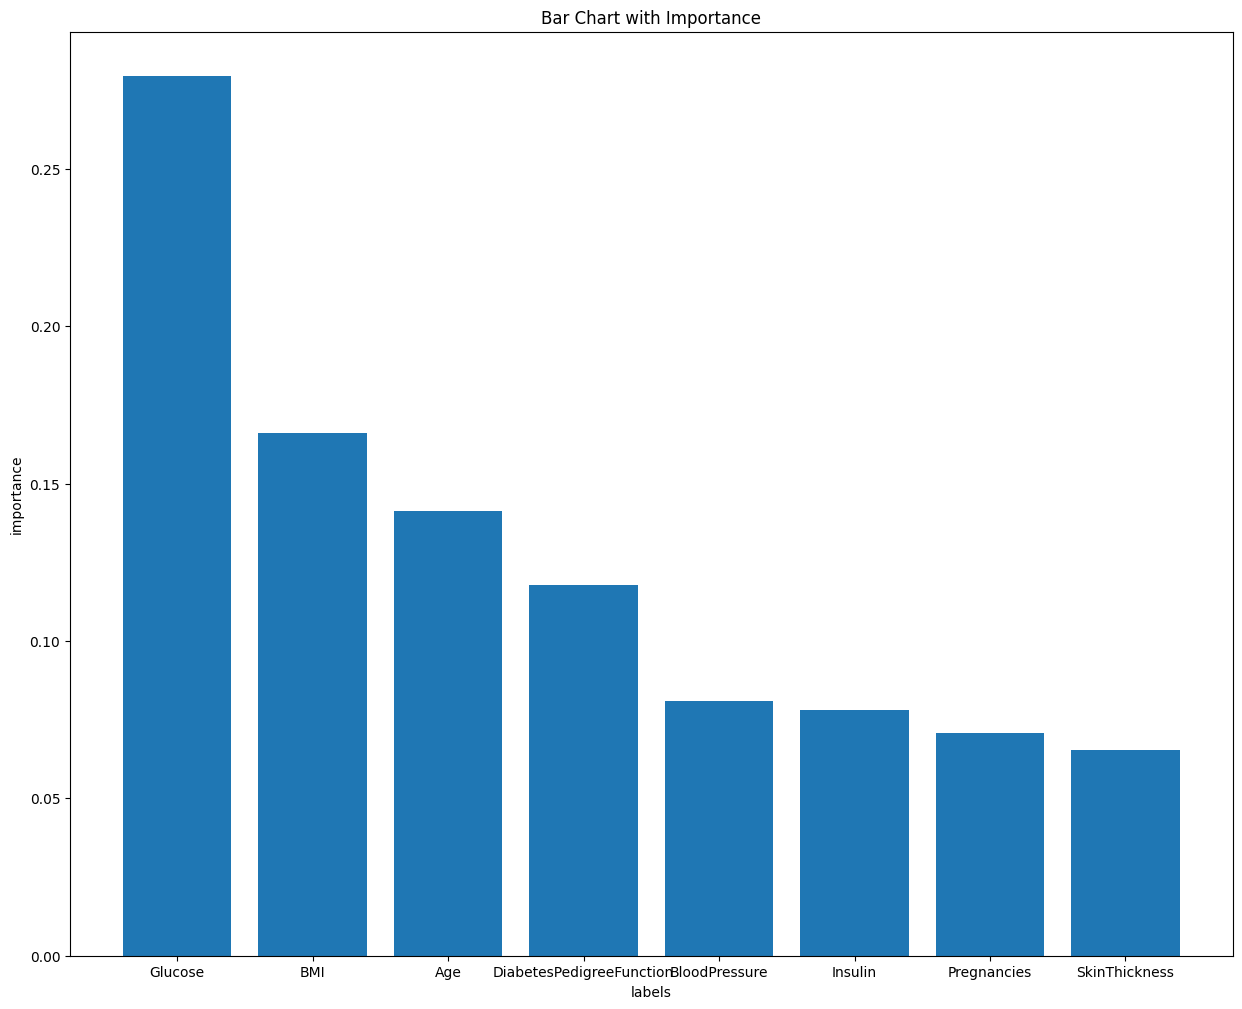

In [107]:
plt.figure(figsize =(15,12))
plt.bar(importance_df['features'], importance_df['importance'])
plt.xlabel('labels')
plt.ylabel('importance')
plt.title('Bar Chart with Importance')

**Evaluate**

In [108]:
acs = accuracy_score(y_test, y_pred)
print("Accuracy_score:", acs)
print("------------------------------")
cm = confusion_matrix(y_test, y_pred)
print("confusion_matrix")
print(cm)
print("--------------------------------")
cr = classification_report(y_test, y_pred)
print("classification_report")
print(cr)
y_prob = best_model.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy_score: 0.9963898916967509
------------------------------
confusion_matrix
[[363   0]
 [  2 189]]
--------------------------------
classification_report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       363
           1       1.00      0.99      0.99       191

    accuracy                           1.00       554
   macro avg       1.00      0.99      1.00       554
weighted avg       1.00      1.00      1.00       554

ROC-AUC: 1.0


**To further verify the model's performance, I used a pipeline with StandardScaler and RandonForestClassifier, followed by 5-fold cross-validation. This provides a more trustworthy measure of model stability and reduces the risk of overly optimistic results from a single split.**

In [109]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        criterion='gini',
        max_features='log2',
        random_state=42
    ))
])

cv_scores = cross_val_score(pipeline, X, Y, cv=5)
print("Pipeline CV accuracy:", cv_scores.mean())

Pipeline CV accuracy: 0.9931342659990469


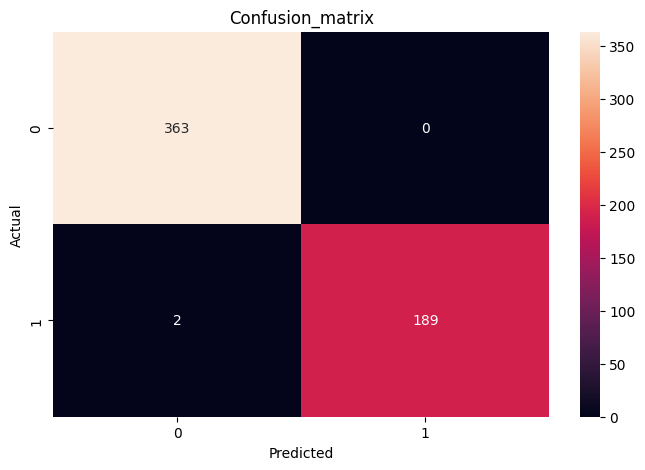

In [110]:
import seaborn as sns

plt.figure(figsize = (8,5))
sns.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion_matrix")
plt.show()

**The Random Forest model achieved high performance. To ensure the results were reliable and not due to potential overfitting or model complexity, we evaluated a simpler baseline model, Logistic Regression, for comparison.**

In [115]:
lr = LogisticRegression()
model_lr = lr.fit(x_train, y_train)
model_lr

LogisticRegression()

In [117]:
model_lr.score(x_test, y_test)

0.7527075812274369

In [129]:
y_predict_lr = model_lr.predict(x_test)
y_predict_lr


array([0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,

In [133]:
as_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy Score: ", as_lr)

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix")
print(cm_lr)

cr_lr = classification_report(y_test, y_pred_lr)
print("classification_report")
print(cr_lr)
y_proba = model_lr.predict_proba(x_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy Score:  0.7527075812274369
Confusion Matrix
[[314  49]
 [ 88 103]]
classification_report
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       363
           1       0.68      0.54      0.60       191

    accuracy                           0.75       554
   macro avg       0.73      0.70      0.71       554
weighted avg       0.75      0.75      0.74       554

ROC-AUC: 0.8315953442083857


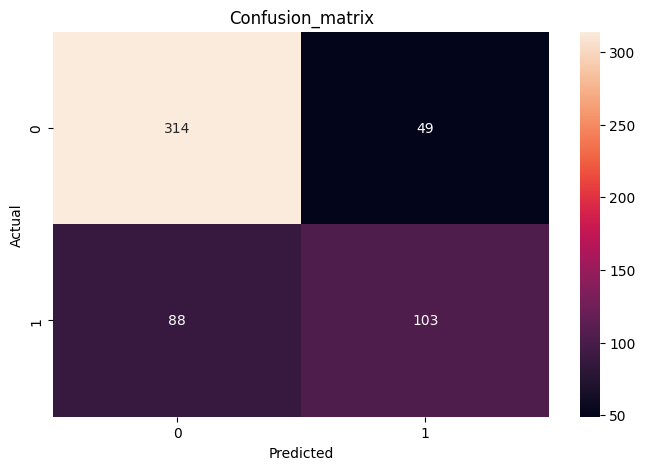

In [134]:
plt.figure(figsize = (8,5))
sns.heatmap(cm_lr, annot = True, fmt = 'd')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion_matrix")
plt.show()

**Logistic Regression provided a reliable baseline with balanced performance. However, compared to Random Forest, it showed lower predictive capability. Therefore, Random Forest was selected as the final model.**

**Sample Prediction: Run the cell below to enter patient health data and estimate diabetes risk.**

In [112]:
print("Please enter patient's health data below: ")
print("==============================================")
Pregnancies = float(input("Pregnancies: "))
Glucose = float(input("Glucose: "))
BloodPressure = float(input("BloodPressure: "))
SkinThickness = float(input("SkinThickness: "))
Insulin = float(input("Insulin: "))
BMI = float(input("BMI: "))
DiabetesPedigreeFunction = float(input("DiabetesPedigreeFunction: "))
Age = float(input("Age: " ))
sample = pd.DataFrame([[
    Pregnancies,
    Glucose,
    BloodPressure,
    SkinThickness,
    Insulin,
    BMI,
    DiabetesPedigreeFunction,
    Age
]],
columns=[
    'Pregnancies','Glucose','BloodPressure','SkinThickness',
    'Insulin','BMI','DiabetesPedigreeFunction','Age'
])

sample[columns] = scaler.transform(sample[columns])
y_pred = best_model.predict(sample)
y_prob = best_model.predict_proba(sample)[0][1]

if y_prob>=0.7:
  risk_level = "High"
elif y_prob >=0.4:
  risk_level = "moderate"
else:
  risk_level = "low"

print("=====================================================")
print("Prediction:", "diabetic" if y_pred ==1 else "Not Diabetic" )
print("The probality: ",y_prob)
print("your risk of getting diabetes is: ", risk_level)



Please enter patient's health data below: 
Pregnancies: 121
Glucose: 121
BloodPressure: 121
SkinThickness: 121
Insulin: 121
BMI: 121
DiabetesPedigreeFunction: 121
Age: 15
Prediction: diabetic
The probality:  0.63
your risk of getting diabetes is:  moderate


**Stored all code in Pickle**

In [135]:
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)